In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from  sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler # x-mean/sd
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import DBSCAN

PART 1

In [3]:
df = pd.read_csv('c:/Users/Ahmed Wael/Downloads/Mall_Customers.csv')
df.head(7)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6


In [4]:
df.duplicated().sum() # Check for duplicate rows
df.isnull().sum()  # Check for missing values
# no duplicates and no missing values

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

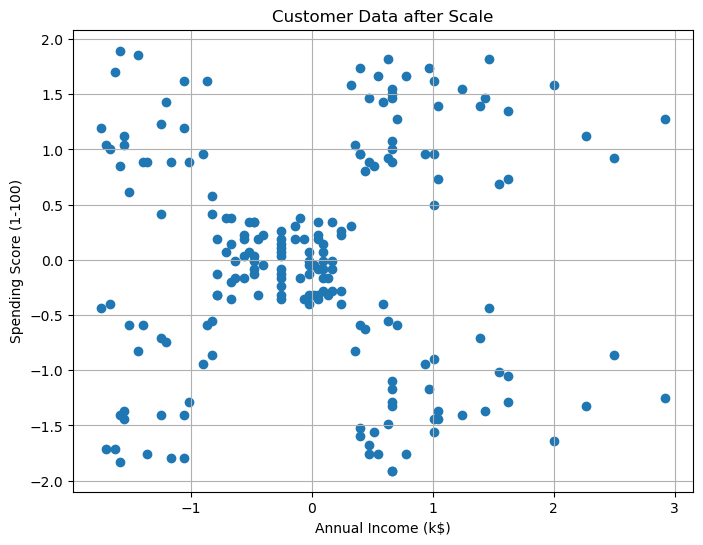

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], marker='o')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Data after Scale')
plt.grid(True)
plt.show()

PART 2

c:\Users\Ahmed Wael\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ahmed Wael\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ahmed Wael\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ahmed Wael\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

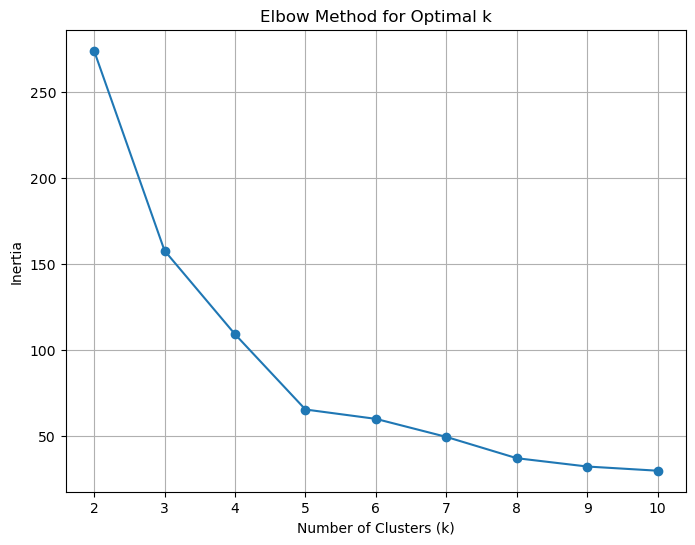

In [7]:
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
# we can see that the elbow is at k=5 and inertia[3] 65.56840815571681

In [8]:
inertia[3]

from sklearn.metrics import silhouette_score
silhouette_score(X_scaled, KMeans(n_clusters=5, random_state=42).fit(X_scaled).labels_)

c:\Users\Ahmed Wael\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0.5546571631111091

In [ ]:
kmeans_5 = KMeans(n_clusters=5, random_state=42)
kmeans_5.fit(X_scaled)
kmeans_5.labels_

c:\Users\Ahmed Wael\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

PART 3

c:\Users\Ahmed Wael\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


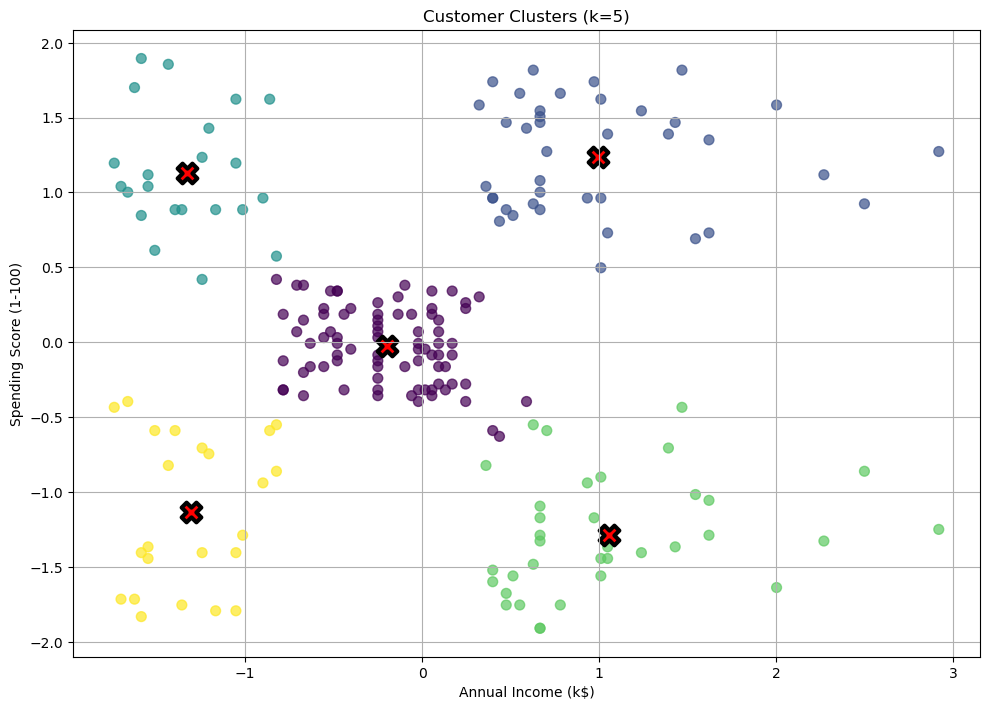

In [ ]:
kmeans_5 = KMeans(n_clusters=5, random_state=42)
kmeans_5.fit(X_scaled)
kmeans_5.labels_

plt.figure(figsize=(10, 7))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_5.labels_, marker='o', cmap='viridis', alpha=0.7,s=50, )
plt.grid(True)
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score')
plt.tight_layout()
plt.title('Customer Clusters (k=5)')

centroids = kmeans_5.cluster_centers_

plt.scatter(centroids[:, 0], centroids[:, 1], 
            marker='X', color='red', s=200, linewidths=3, edgecolors='black')

plt.show()

PART 4

In [ ]:
from sklearn.datasets import make_moons
X_moon, y_moon = make_moons(n_samples=500, noise=0.05, random_state=42)


array([[ 0.83058575, -0.44773257],
       [ 0.70167816,  0.81691843],
       [ 1.02208004, -0.49257102],
       [-0.31676455,  0.95343844],
       [ 0.29322631,  1.05718523]])

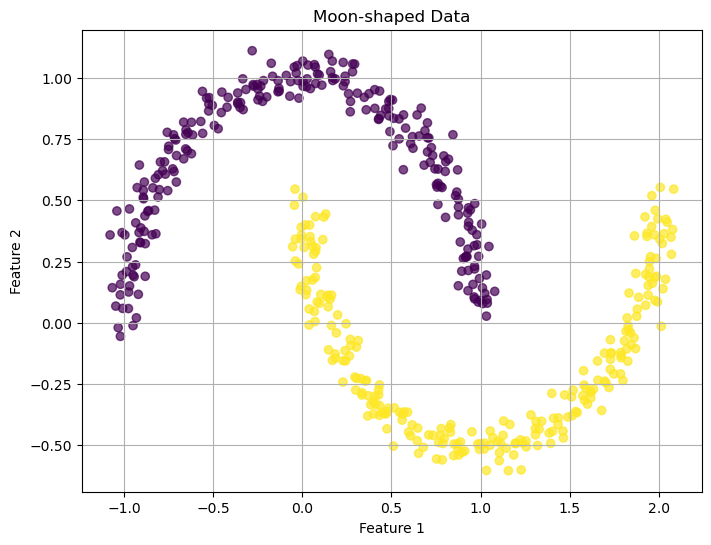

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(X_moon[:,0], X_moon[:,1], c=y_moon, marker='o', alpha=0.7, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2') 
plt.title('Moon-shaped Data')
plt.grid(True)  
plt.show()

c:\Users\Ahmed Wael\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Ahmed Wael\AppData\Local\Temp\ipykernel_6000\1389248894.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_moon[:,0], X_moon[:,1], c='red', marker='o', alpha=0.7, cmap='coolwarm')


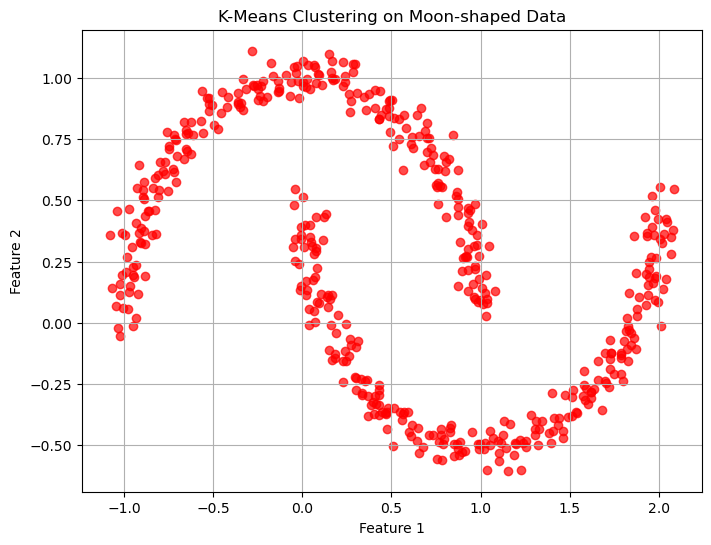

In [ ]:
# step 2
kmeans_moon = KMeans(n_clusters=2, random_state=42)
kmeans_moon.fit(X_moon)
labels_moon = kmeans_moon.labels_

plt.figure(figsize=(8, 6))
plt.scatter(X_moon[:,0], X_moon[:,1], c='labels_moon', marker='o', alpha=0.7, cmap='coolwarm')
plt.xlabel('Feature 1') 
plt.ylabel('Feature 2')
plt.title('K-Means Clustering on Moon-shaped Data')
plt.grid(True)
plt.show()

# it fails because on the top frawn it should
#  all be one color but its not and the bottom
#  it also fails because it should all be one color but its not

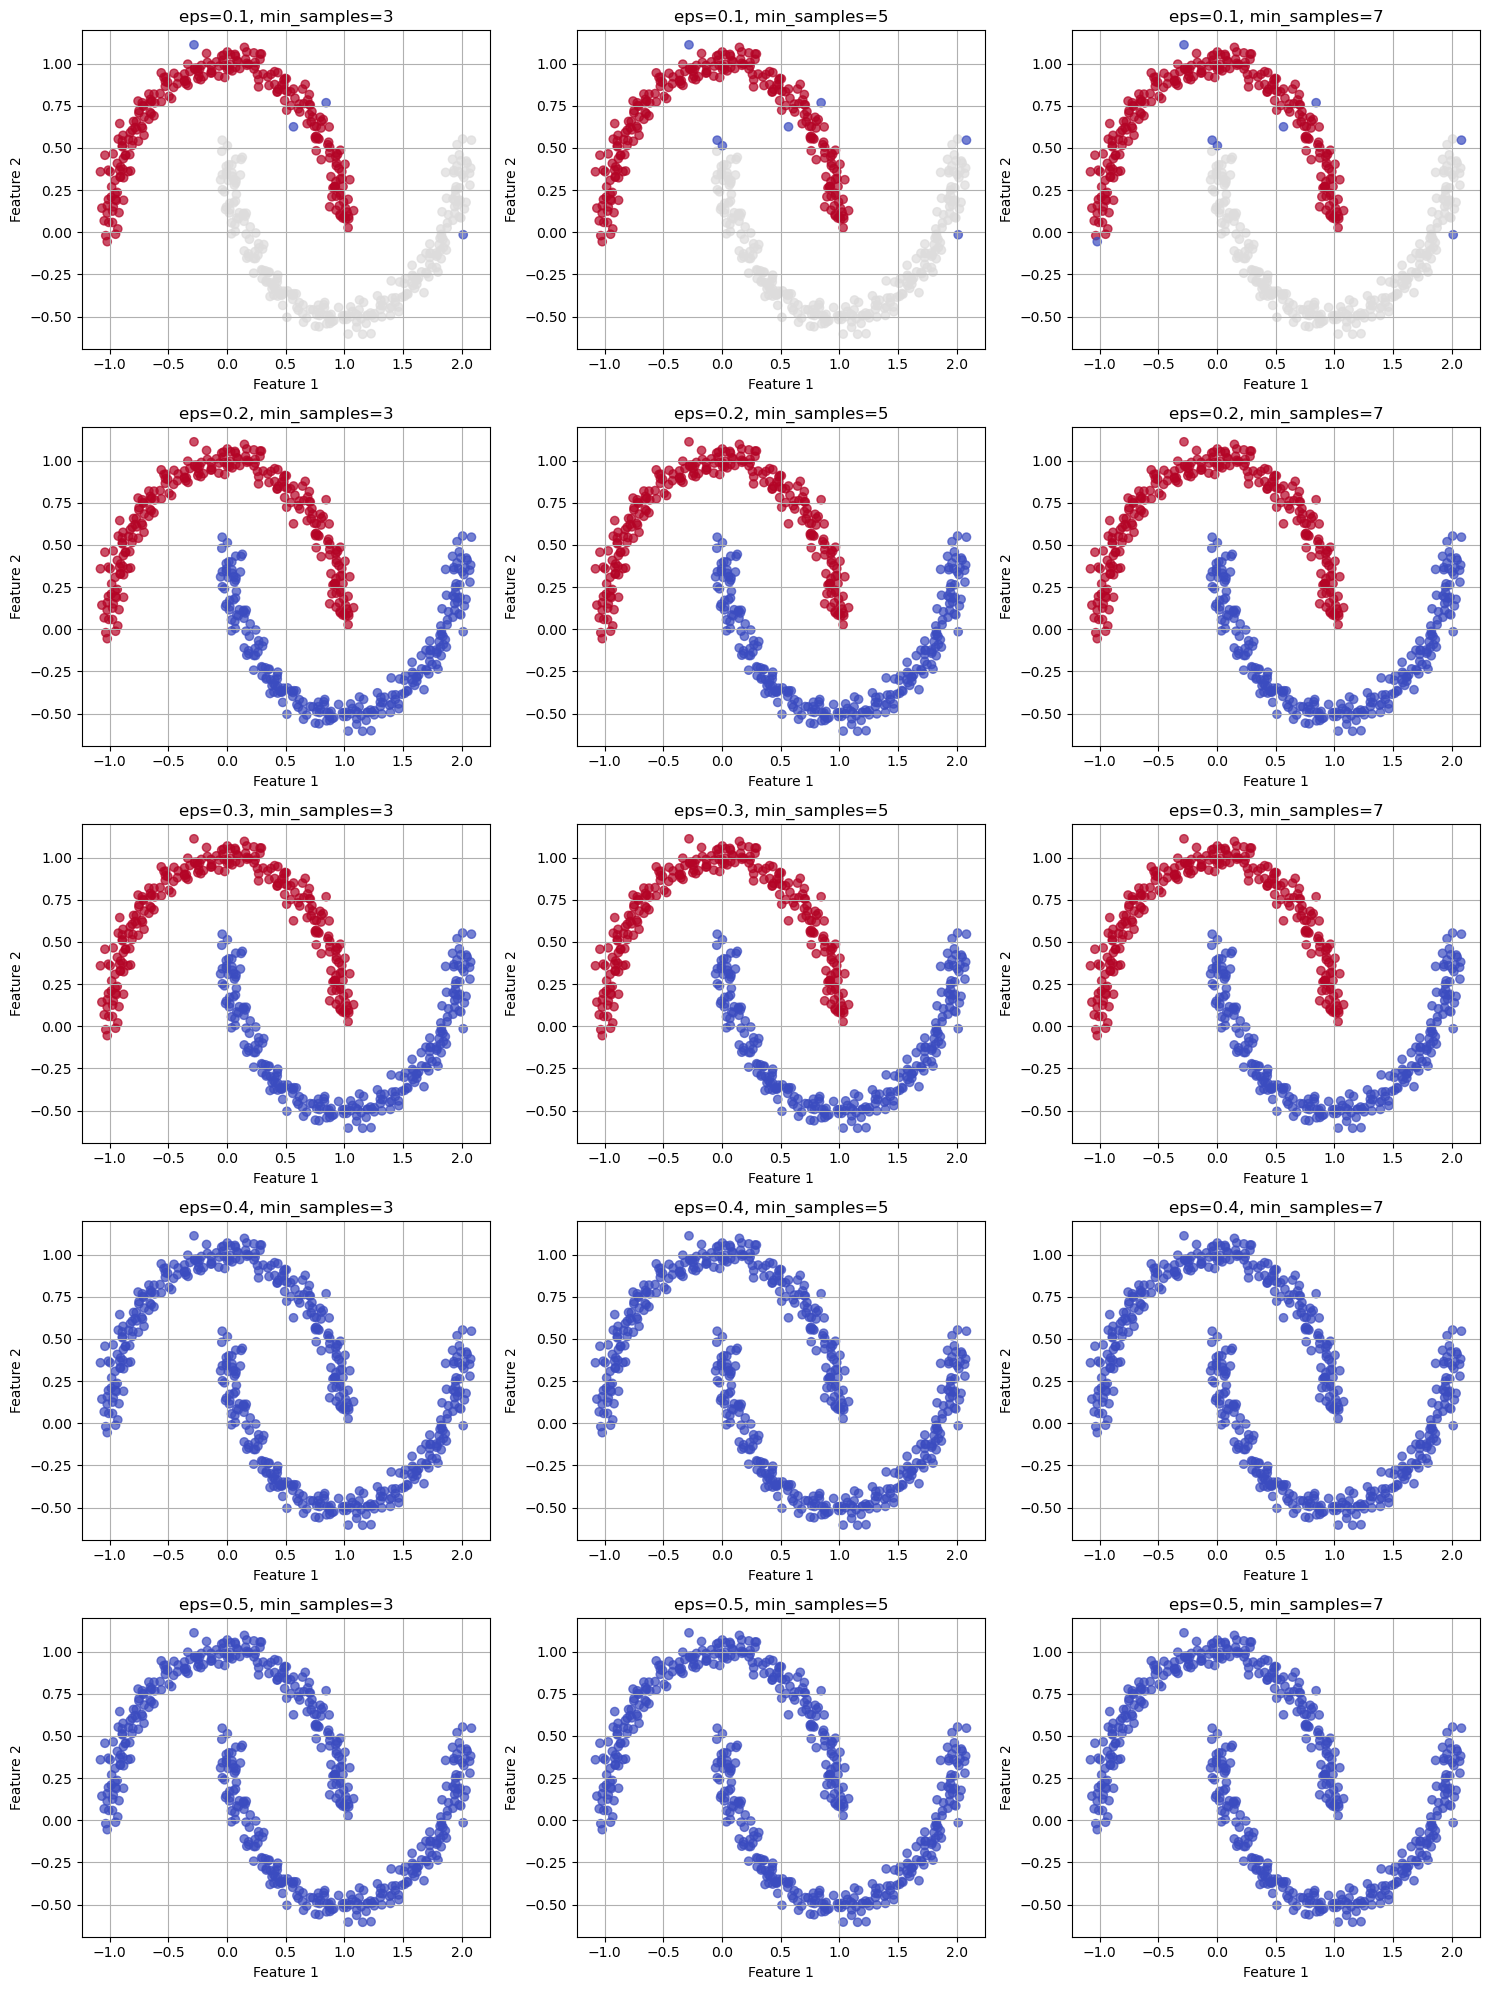

In [43]:
# step 3
param_combinations = [
    (0.1, 3), (0.1, 5), (0.1, 7),
    (0.2, 3), (0.2, 5), (0.2, 7),
    (0.3, 3), (0.3, 5), (0.3, 7),  # This one likely works best
    (0.4, 3), (0.4, 5), (0.4, 7),
    (0.5, 3), (0.5, 5), (0.5, 7),
]

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.flatten()

for i, (eps, min_samples) in enumerate(param_combinations):
    dbscan = DBSCAN(min_samples=min_samples, eps=eps)
    labels_dbscan = dbscan.fit_predict(X_moon)
    axes[i].scatter(X_moon[:,0], X_moon[:,1], c=labels_dbscan, marker='o', alpha=0.7, cmap='coolwarm')
    axes[i].set_title(f'eps={eps}, min_samples={min_samples}')
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')
    axes[i].grid(True)
plt.tight_layout()
plt.show()

conclusion:
K_means clustering is used to split data and trying to find the correct number of clusters to split them apart and it worked well
with customer data and found to best k value by silhoutte score and elbow method

However, on a different data shape like the moon it failed to correctly seperate the data as showed in step 2 and dbscan fixes this by choosing
a random point and seeing how many points it intersects by n_samples and esp which is the distance the circle can go to
thats why it succeeded in the moon shape dataset